# Exploration — California Housing Raw

Analyse exploratoire du dataset stocké en DuckDB par `data_load.ipynb`.

Au programme :
1. Lecture depuis la base
2. Statistiques descriptives
3. Distributions des features
4. Matrice de corrélation
5. Distribution géographique du prix

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")

TARGET = "MedHouseVal"
DB_PATH = Path("../data/raw/california_housing.db")

## 1. Lecture depuis DuckDB

In [2]:
con = duckdb.connect(str(DB_PATH), read_only=True)
df = con.sql("SELECT * FROM housing").df()
con.close()

print(f"Shape : {df.shape}")
df.head()

Shape : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Statistiques descriptives

`describe()` donne une vue d'ensemble (min, max, quartiles, moyenne) — utile pour repérer des échelles très différentes entre features et des outliers évidents.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 3. Distributions des features

Histogrammes de chaque variable — on cherche des skew importants, des queues lourdes, des plafonds (capping) ou des valeurs constantes.

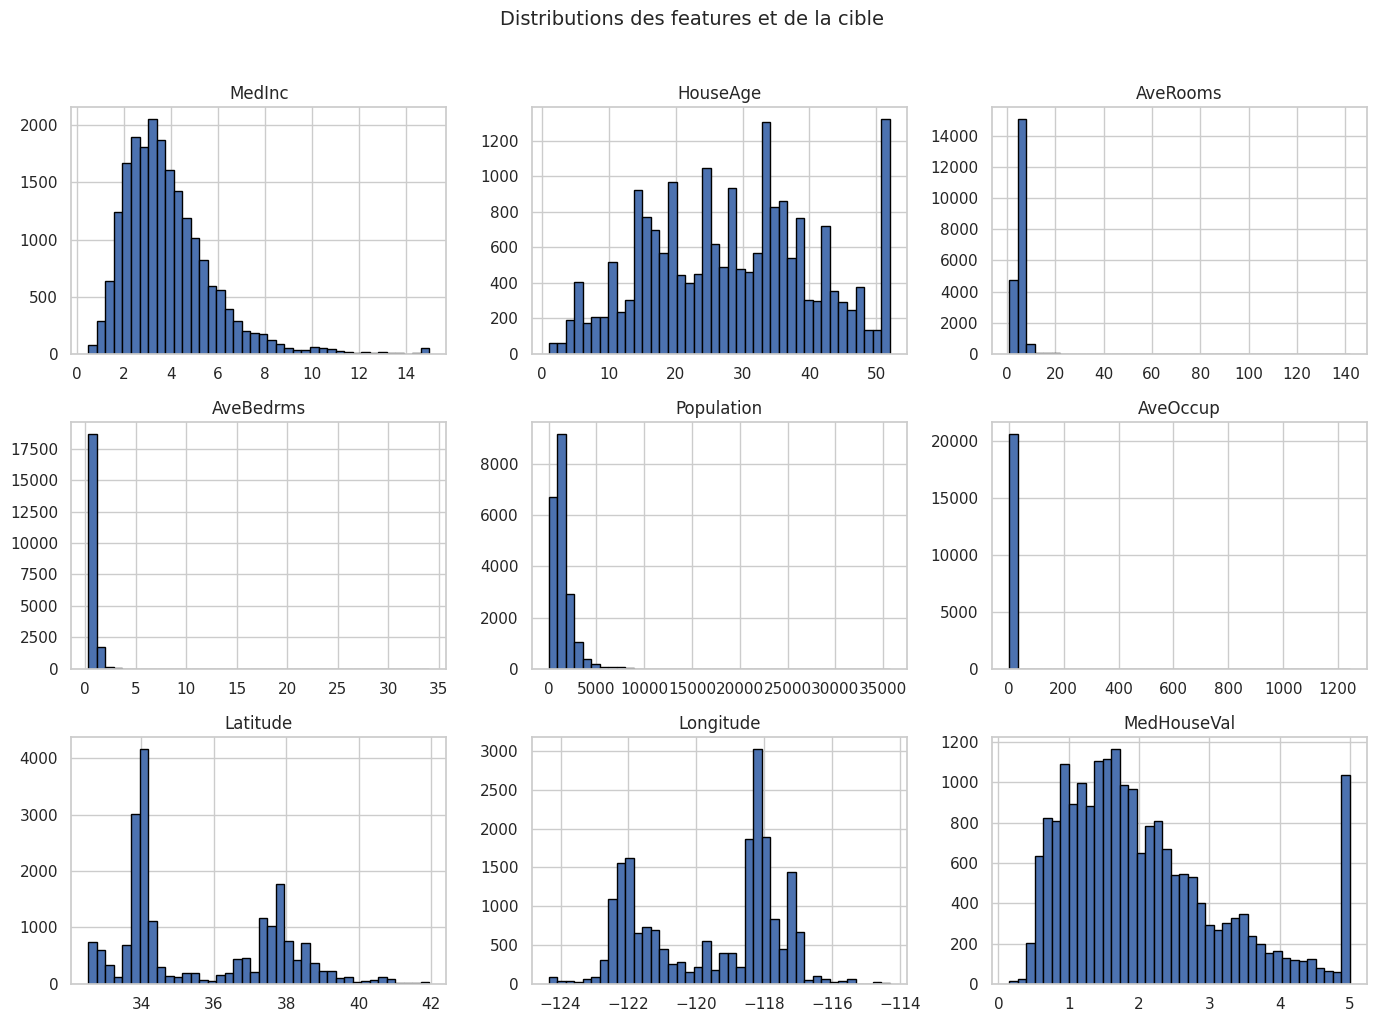

In [5]:
df.hist(bins=40, figsize=(14, 10), edgecolor="black")
plt.suptitle("Distributions des features et de la cible", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Matrice de corrélation

On regarde les corrélations linéaires entre features et avec la cible. `MedInc` (revenu médian) est attendu comme le prédicteur principal du prix.

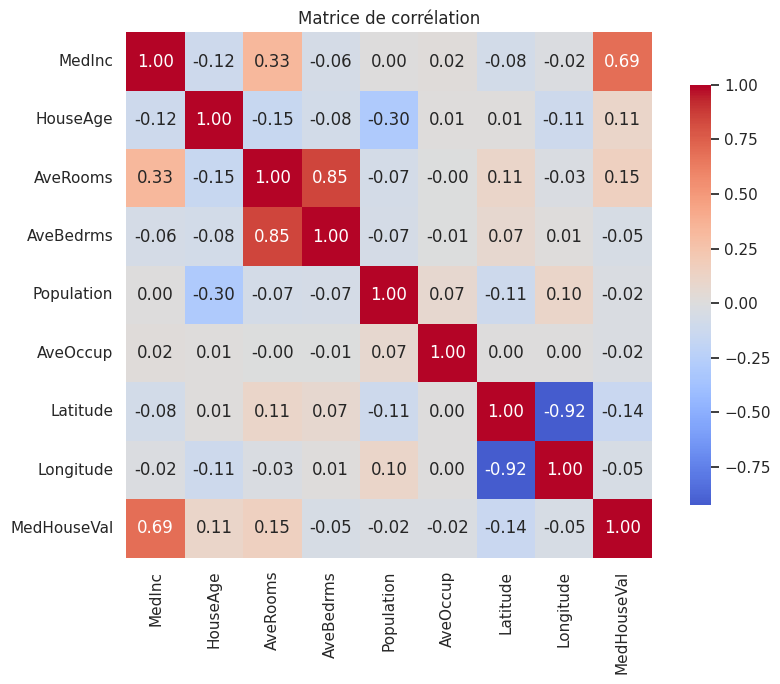

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [6]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

corr[TARGET].sort_values(ascending=False)

## 5. Distribution géographique

Chaque point = un secteur en Californie. La couleur encode le prix médian — on s'attend à voir des prix élevés sur la côte (San Francisco, Los Angeles).

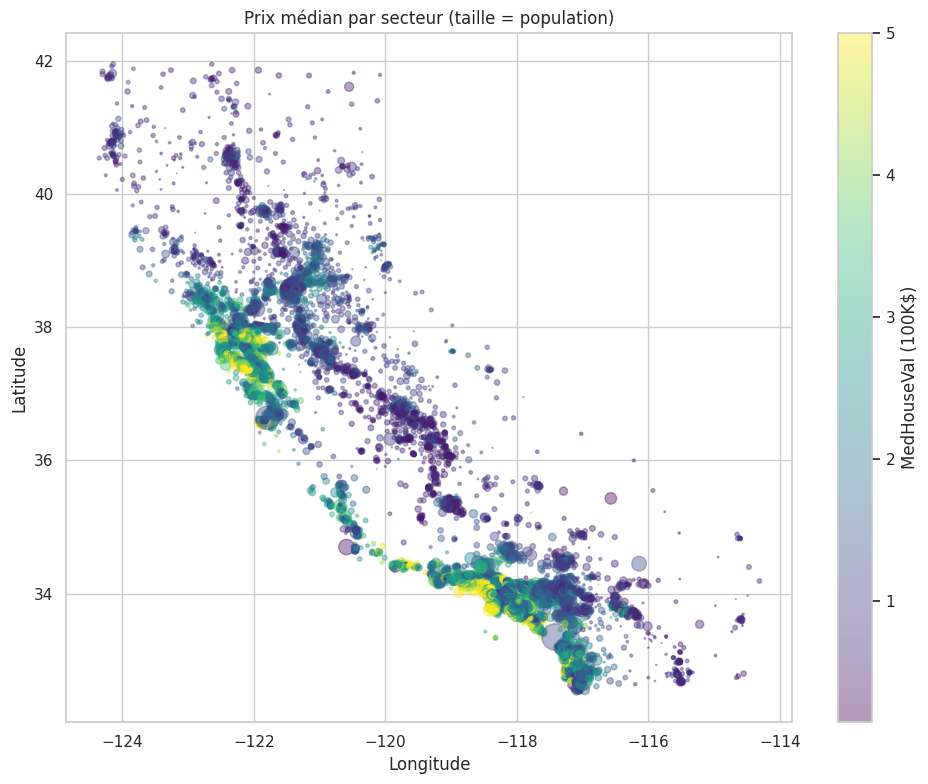

In [7]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df[TARGET],
    s=df["Population"] / 100,
    cmap="viridis",
    alpha=0.4,
)
plt.colorbar(sc, label="MedHouseVal (100K$)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Prix médian par secteur (taille = population)")
plt.tight_layout()
plt.show()

## 6. Valeurs manquantes

Le dataset California Housing est connu pour être complet, mais on vérifie systématiquement.

In [8]:
missing = pd.DataFrame({
    "n_missing": df.isnull().sum(),
    "pct_missing": df.isnull().mean() * 100,
})
missing.sort_values("n_missing", ascending=False)

,n_missing,pct_missing
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
MedHouseVal,0,0.0


## 7. Valeurs aberrantes (outliers)

On utilise la règle de **Tukey (IQR)** : un point est outlier s'il est en dehors de `[Q1 - 1.5·IQR ; Q3 + 1.5·IQR]`.

On s'attend à des outliers marqués sur :
- `AveRooms`, `AveBedrms`, `AveOccup` : ratios calculés sur des secteurs peu peuplés → valeurs extrêmes
- `Population` : très étalée
- `MedHouseVal` : capping à 5.0 (limite supérieure visible dans les histogrammes)

On exclut `Latitude`/`Longitude` (coordonnées géographiques, pas de notion d'aberrant).

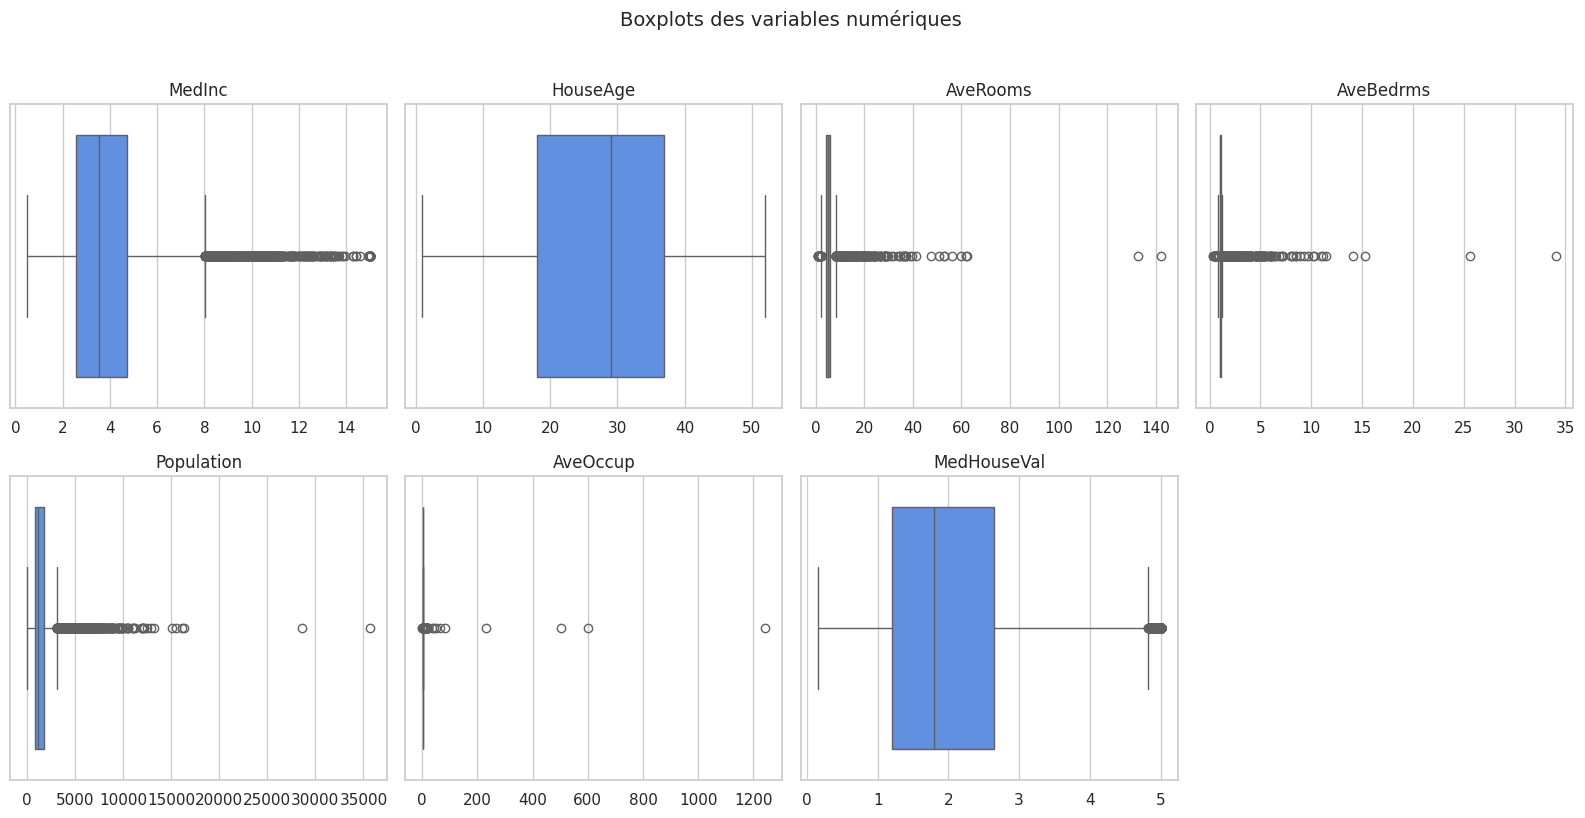

In [9]:
numeric_features = [c for c in df.columns if c not in ("Latitude", "Longitude")]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), numeric_features):
    sns.boxplot(x=df[col], ax=ax, color="#4c8bf5")
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.ravel()[len(numeric_features):]:
    ax.axis("off")
plt.suptitle("Boxplots des variables numériques", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
def iqr_outliers(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

outliers = pd.DataFrame({
    col: {
        "n_outliers": iqr_outliers(df[col]).sum(),
        "pct_outliers": iqr_outliers(df[col]).mean() * 100,
    }
    for col in numeric_features
}).T.sort_values("n_outliers", ascending=False)

outliers

,n_outliers,pct_outliers
AveBedrms,1424.0,6.899225
Population,1196.0,5.794574
MedHouseVal,1071.0,5.188953
AveOccup,711.0,3.444767
MedInc,681.0,3.299419
AveRooms,511.0,2.475775
HouseAge,0.0,0.000000


### Conclusion

- **Pas de valeurs manquantes** : aucun traitement d'imputation nécessaire.
- **Outliers présents** sur `AveOccup`, `AveRooms`, `AveBedrms`, `Population` — typiques de ce dataset (secteurs très peu peuplés).
- **Cible cappée à 5.0** (visible dans l'histogramme et les boxplots) : c'est une caractéristique du dataset original, pas une erreur.

**Choix de modélisation** : on **garde** les outliers tels quels — leur suppression biaiserait le modèle pour les secteurs hauts revenus / faible densité. Un modèle robuste (Random Forest, GBM) gèrera très bien.